### Today we are tackling a core Supply Chain and Operations challenge: predicting future demand and calculating the optimal time to reorder stock. The goal is to avoid stockouts while minimizing excess inventory holding costs.

#### Step 1: Simulating Historical Data
To build our model, we will generate 6 months of daily sales data for a high-rotation SKU. We apply a normal distribution and a slight upward trend to mimic realistic, noisy market behavior.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt

# ### Day 10: Demand Forecasting and Inventory Replenishment Strategy
# #### Today we will build a predictive statistical model to calculate Moving Averages, Safety Stock, and the Reorder Point (ROP) for a high-rotation SKU.

# #### Step 1: Simulating 6 months of historical daily sales data
# We use numpy to generate a normal distribution of sales with a slight upward trend to simulate realistic market behavior.
np.random.seed(42)
dates = pd.date_range(start='2026-03-01', end='2026-08-31', freq='D')

base_demand = np.random.normal(loc=50, scale=15, size=len(dates))
trend = np.linspace(0, 20, len(dates))
sales = np.maximum(base_demand + trend, 0).astype(int) 

df_demand = pd.DataFrame({'Date': dates, 'Units_Sold': sales})
df_demand.set_index('Date', inplace=True)

print("Historical Demand Dataset (First 5 rows):")
display(df_demand.head())

Historical Demand Dataset (First 5 rows):


,Units_Sold
Date,
2026-03-01,57
2026-03-02,48
2026-03-03,59
2026-03-04,73
2026-03-05,46


#### Step 2: Smoothing Volatility with Moving Averages
Raw daily sales data is often too erratic for strategic decision-making. We will calculate a 7-day Short-Term Simple Moving Average (SMA) to capture recent shifts, and a 30-day Long-Term SMA to identify the underlying baseline trend.

In [4]:
# #### Step 2: Calculating Forecasting Metrics (Moving Averages & Standard Deviation)
# We calculate a 7-day Short-Term Moving Average (SMA) to capture recent trends and a 30-day Long-Term SMA for the baseline.
df_demand['7_Day_SMA'] = df_demand['Units_Sold'].rolling(window=7).mean()
df_demand['30_Day_SMA'] = df_demand['Units_Sold'].rolling(window=30).mean()

#### Step 3: Statistical Reorder Point (ROP) & Safety Stock
To prevent out-of-stock scenarios, Operations needs a mathematical trigger to place a new purchase order. This depends on two variables:
- **Lead Time:** The time it takes for the supplier to deliver (Assumed: 14 days).
- **Service Level:** The desired probability of not stocking out (Assumed: 95%, Z-score = 1.65).
We will calculate the standard deviation of recent demand to define the Safety Stock and the final ROP.

In [5]:
# #### Step 3: Safety Stock and Reorder Point (ROP) Calculation
# Assumptions for this specific supplier:
# - Lead Time (days it takes for the supplier to deliver): 14 days
# - Target Service Level: 95% (Z-score of 1.65)

lead_time_days = 14
z_score = 1.65

# We use the most recent 90 days to calculate current demand volatility
recent_90_days = df_demand.tail(90)
std_dev_demand = recent_90_days['Units_Sold'].std()
avg_daily_demand = recent_90_days['Units_Sold'].mean()

# Safety Stock formula: Z-score * Standard Deviation of Demand * SQRT(Lead Time)
safety_stock = int(z_score * std_dev_demand * np.sqrt(lead_time_days))

# Reorder Point formula: (Average Daily Demand * Lead Time) + Safety Stock
reorder_point = int((avg_daily_demand * lead_time_days) + safety_stock)

print(f"Calculated Safety Stock to prevent stockouts: {safety_stock} units")
print(f"Strategic Reorder Point (Trigger new purchase order): {reorder_point} units")

Calculated Safety Stock to prevent stockouts: 94 units
Strategic Reorder Point (Trigger new purchase order): 1009 units


#### Step 4: Executive Visualization
A statistical model must be easily interpretable by management. We will plot the demand trends alongside our calculated inventory thresholds (Safety Stock and ROP) to provide a clear, actionable visual for the purchasing team.

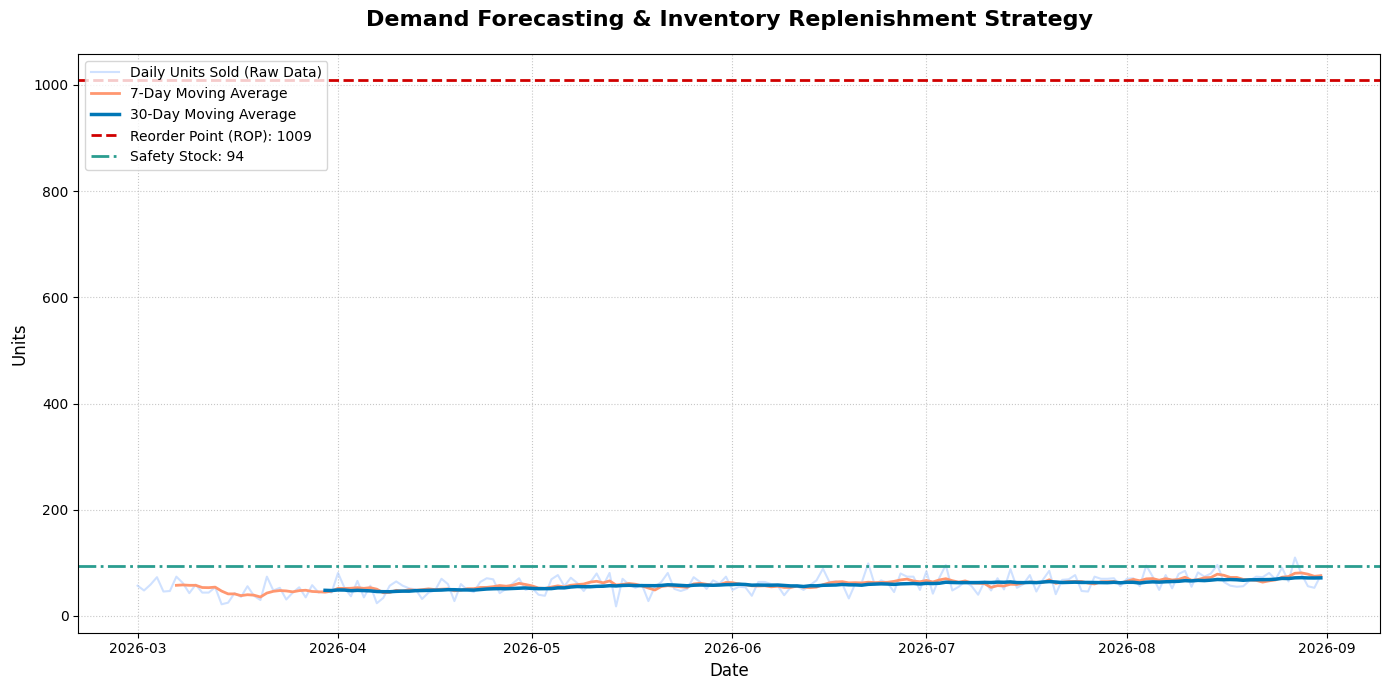

In [6]:
# #### Step 4: Visualizing the Forecasting Model and Inventory Thresholds
plt.figure(figsize=(14, 7))

# Plotting the real data and the moving averages
plt.plot(df_demand.index, df_demand['Units_Sold'], label='Daily Units Sold (Raw Data)', color='#a0c4ff', alpha=0.5, linewidth=1.5)
plt.plot(df_demand.index, df_demand['7_Day_SMA'], label='7-Day Moving Average', color='#ff9770', linewidth=2)
plt.plot(df_demand.index, df_demand['30_Day_SMA'], label='30-Day Moving Average', color='#0077b6', linewidth=2.5)

# Adding strategic thresholds
plt.axhline(y=reorder_point, color='#d00000', linestyle='--', linewidth=2, label=f'Reorder Point (ROP): {reorder_point}')
plt.axhline(y=safety_stock, color='#2a9d8f', linestyle='-.', linewidth=2, label=f'Safety Stock: {safety_stock}')

plt.title('Demand Forecasting & Inventory Replenishment Strategy', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Units', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()

plt.show()